# 311 Service Requests

Only extends from 2010-2025

In [4]:
# Setup

import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath("..")) 
from src.fetch_analysis_311 import *
from src.enforcement_patterns import plot_kde_map

FIGURES_DIR = "../outputs"
os.makedirs(FIGURES_DIR, exist_ok=True)

DATA_DIR = "../data/raw"
os.makedirs(DATA_DIR, exist_ok=True)

# Load council district shapefile
nycc = gpd.read_file(f"{DATA_DIR}/council_districts_26/nycc.shp")



## Pulling 311 Request Data

In [ ]:
# Pulling 2020 - 2025

requests_2020_2025 = fetch_and_save(
    resource_id="erm2-nwe9",
    date_filter="created_date < '2026-01-01T00:00:00'",
    out_path=f"{DATA_DIR}/311_requests/requests_2020_2025.csv",
)

# Pulling 2010 - 2019

requests_2010_2019 = fetch_and_save(
    resource_id="76ig-c548",
    date_filter=None,
    out_path=f"{DATA_DIR}/311_requests/requests_2010_2019.csv",
)

[erm2-nwe9] Fetched 50000 rows so far...
[erm2-nwe9] Fetched 100000 rows so far...
[erm2-nwe9] Fetched 121139 rows so far...
[erm2-nwe9] Done. Total rows: 121139
[76ig-c548] Fetched 23024 rows so far...
[76ig-c548] Done. Total rows: 23024


In [10]:
# Merging
requests_2010_2025 = pd.concat([requests_2010_2019, requests_2020_2025], ignore_index = True)

# Filtering the violation of park rules
vending_descriptors = ['Unlicensed Vendors', 'Food']

mask = (
    (requests_2010_2025['complaint_type'] != 'Violation of Park Rules') |  # keep all non-park rows
    (requests_2010_2025['descriptor'].isin(vending_descriptors))            # keep only vending park rows
)

requests_2010_2025 = requests_2010_2025[mask]

requests_2010_2025_gdf = gpd.GeoDataFrame(requests_2010_2025,
                                      geometry=gpd.points_from_xy(requests_2010_2025['longitude'], requests_2010_2025['latitude']),
                                      crs = "EPSG:4326").to_crs("EPSG:2263")

requests_2010_2025.to_csv(f"{DATA_DIR}/311_requests/requests_2010_2025.csv", index = False)

## Analysis

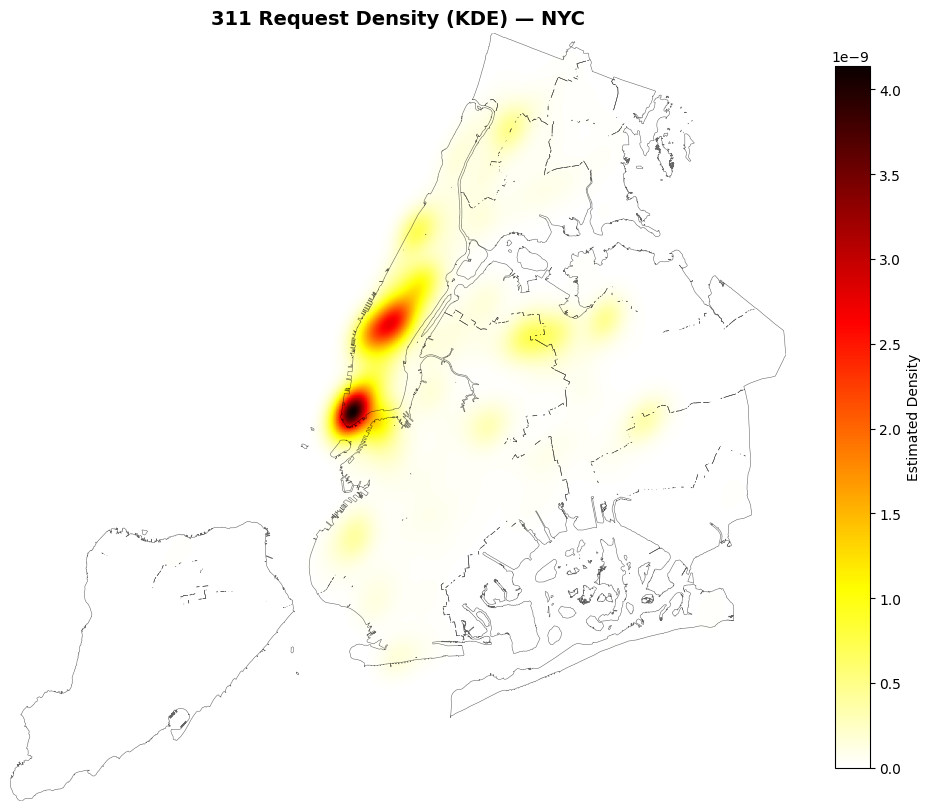

In [8]:
# KDE Map
fig, ax = plt.subplots(figsize=(10, 12))

plot_kde_map(
    requests_2010_2025_gdf,
    boundary_gdf=nycc.dissolve(),
    title='311 Request Density (KDE) — NYC',
    ax=ax
)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/311_request_density.png")
plt.show()

<Axes: title={'center': '311 Requests by Agency'}>

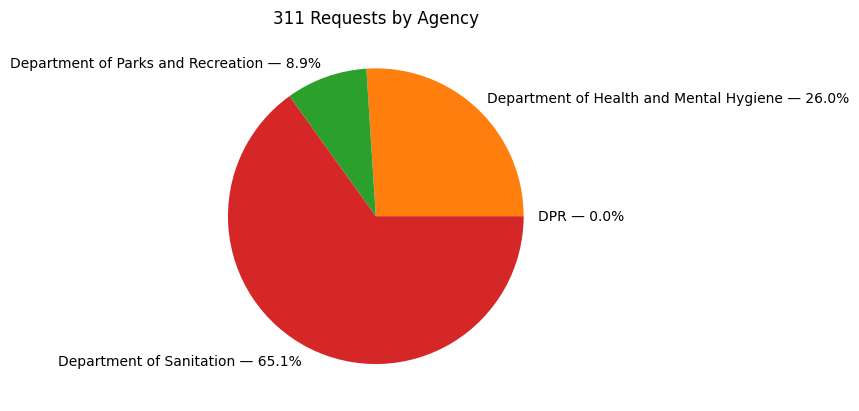

In [9]:
agency_grouped = requests_2010_2025.groupby("agency_name").size()

total = agency_grouped.sum()
labels = [f"{name} — {count/total*100:.1f}%"
          for name, count in agency_grouped.items()]

agency_grouped.plot(kind="pie", labels=labels, ylabel="", title = "311 Requests by Agency")

In [11]:
# Spatial Breakdown by Agency

plot_all_maps(requests_2010_2025_gdf, agencies)

NameError: name 'agencies' is not defined


plot_all_maps(requests_2010_2025_gdf, agencies)